<h3>LIBRERIAS</h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

<h3>CARGAR</h3>

In [2]:
ruta = Path(r"../1. Datasets/2. Dataset Limpio")

df = pd.read_parquet(ruta/"social_media_usage.parquet")

In [3]:
df.head()

,id_usuario,anio,pais,grupo_edad,genero,plataforma,horas_pantalla_diaria,frecuencia_doomscrolling,exposicion_recomendacion_ia,pct_perdida_productividad,nivel_riesgo_adiccion,uso_pantalla_categoria,doomscrolling_categoria
0,15144,2012,Saudi Arabia,Young Adult,Other,Facebook,5.95,8.85,52.56,44.09,Low,Moderado,Severo
1,16982,2019,Indonesia,Teen,Other,Facebook,5.57,6.75,80.72,10.83,High,Moderado,Severo
2,23139,2011,Indonesia,Teen,Male,LinkedIn,6.32,3.05,41.47,62.77,Medium,Alto,Moderado
3,4233,2013,India,Young Adult,Other,LinkedIn,6.77,7.39,94.06,15.06,Medium,Alto,Severo
4,7827,2025,Pakistan,Senior,Male,Facebook,4.25,1.23,78.12,18.34,High,Moderado,Leve


In [5]:
df.columns

Index(['id_usuario', 'anio', 'pais', 'grupo_edad', 'genero', 'plataforma',
       'horas_pantalla_diaria', 'frecuencia_doomscrolling',
       'exposicion_recomendacion_ia', 'pct_perdida_productividad',
       'nivel_riesgo_adiccion', 'uso_pantalla_categoria',
       'doomscrolling_categoria'],
      dtype='object')

In [14]:
df = df[df['anio'].between(2010, 2025)]

df

,id_usuario,anio,pais,grupo_edad,genero,plataforma,horas_pantalla_diaria,frecuencia_doomscrolling,exposicion_recomendacion_ia,pct_perdida_productividad,nivel_riesgo_adiccion
9,15144,2012,Saudi Arabia,Young Adult,Other,Facebook,5.95,8.85,52.56,44.09,Low
11,16982,2019,Indonesia,Teen,Other,Facebook,5.57,6.75,80.72,10.83,High
21,23139,2011,Indonesia,Teen,Male,LinkedIn,6.32,3.05,41.47,62.77,Medium
27,4233,2013,India,Young Adult,Other,LinkedIn,6.77,7.39,94.06,15.06,Medium
28,7827,2025,Pakistan,Senior,Male,Facebook,4.25,1.23,78.12,18.34,High
...,...,...,...,...,...,...,...,...,...,...,...
49987,424,2013,Nigeria,Young Adult,Female,Twitch,3.56,8.24,11.40,4.77,Low
49988,6743,2022,Italy,Teen,Male,Facebook,6.77,0.61,15.90,60.26,High
49992,11350,2014,South Korea,Adult,Male,Instagram,5.92,4.58,75.95,14.42,Medium
49994,18438,2016,UAE,Senior,Male,X/Twitter,3.63,4.65,42.62,47.62,Low


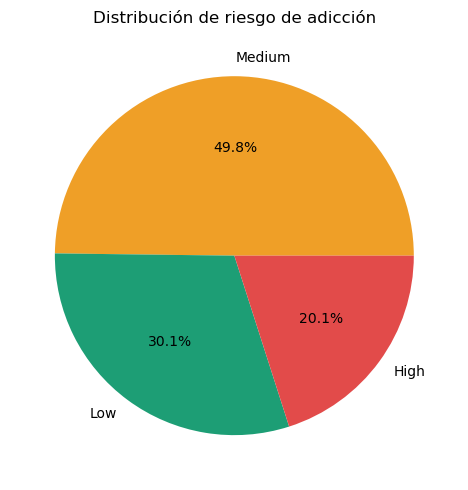

In [15]:
# 2. DISTRIBUCIÓN DE RIESGO DE ADICCIÓN
fig, ax = plt.subplots(figsize=(5,5))
df['nivel_riesgo_adiccion'].value_counts().plot.pie(
    autopct='%1.1f%%', ax=ax,
    colors=['#EF9F27','#1D9E75','#E24B4A']
)
ax.set_title('Distribución de riesgo de adicción')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

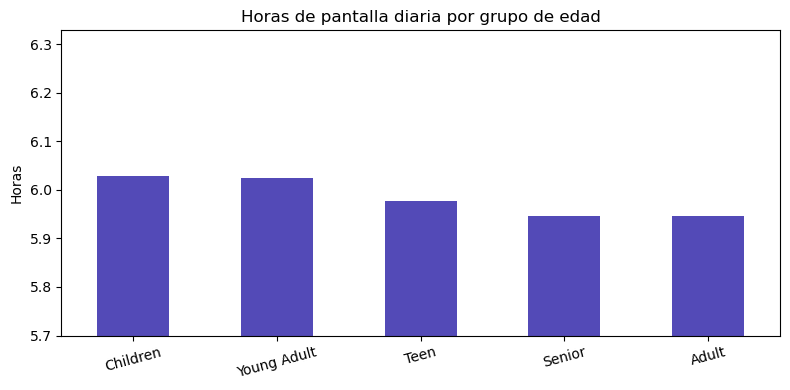

In [ ]:
# 2. HORAS DE PANTALLA POR GRUPO DE EDAD 
edad_pantalla = df.groupby('grupo_edad')['horas_pantalla_diaria'].mean().sort_values(ascending=False)
edad_pantalla.plot(kind='bar', figsize=(8, 4), color='#534AB7')
plt.title('Horas de pantalla diaria por grupo de edad')
plt.ylabel('Horas')
plt.ylim(5.7, edad_pantalla.max() + 0.3)
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

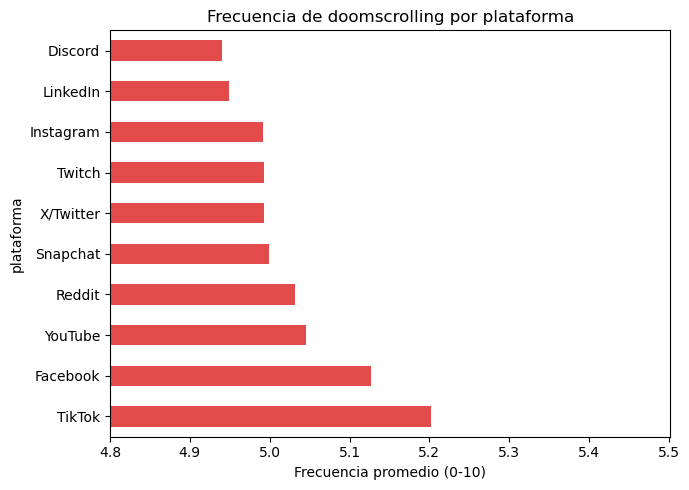

In [ ]:
# 3. DOOMSCROLLING POR PLATAFORMA
plat_doom = df.groupby('plataforma')['frecuencia_doomscrolling'].mean().sort_values(ascending=False)
plat_doom.plot(kind='barh', figsize=(7, 5), color='#E24B4A')
plt.title('Frecuencia de doomscrolling por plataforma')
plt.xlabel('Frecuencia promedio (0-10)')
plt.xlim(4.8, plat_doom.max() + 0.3)
plt.tight_layout()
plt.show()

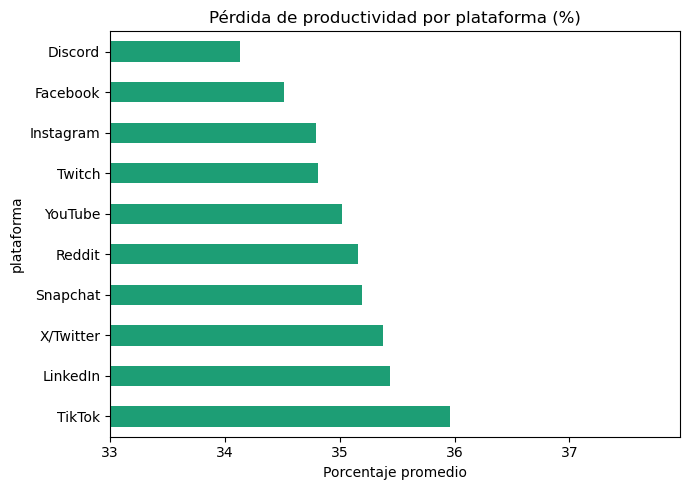

In [ ]:
# 4. PÉRDIDA DE PRODUCTIVIDAD POR PLATAFORMA
plat_prod = df.groupby('plataforma')['pct_perdida_productividad'].mean().sort_values(ascending=False)
plat_prod.plot(kind='barh', figsize=(7, 5), color='#1D9E75')
plt.title('Pérdida de productividad por plataforma (%)')
plt.xlabel('Porcentaje promedio')
plt.xlim(33, plat_prod.max() + 2)
plt.tight_layout()
plt.show()

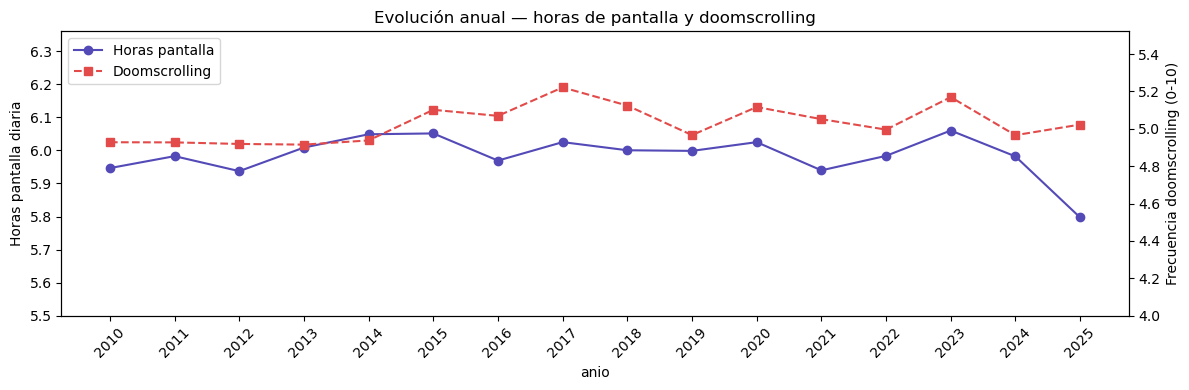

In [ ]:
# --- 5. EVOLUCIÓN ANUAL — HORAS PANTALLA Y DOOMSCROLLING ---
anio_pantalla = df.groupby('anio')[['horas_pantalla_diaria', 'frecuencia_doomscrolling']].mean()

fig, ax = plt.subplots(figsize=(12, 4))
anio_pantalla['horas_pantalla_diaria'].plot(ax=ax, marker='o', color='#534AB7', label='Horas pantalla')
ax2 = ax.twinx()
anio_pantalla['frecuencia_doomscrolling'].plot(ax=ax2, marker='s', color='#E24B4A', label='Doomscrolling', linestyle='--')
ax.set_title('Evolución anual — horas de pantalla y doomscrolling')
ax.set_ylabel('Horas pantalla diaria')
ax2.set_ylabel('Frecuencia doomscrolling (0-10)')
ax.set_ylim(5.5, anio_pantalla['horas_pantalla_diaria'].max() + 0.3)
ax2.set_ylim(4, anio_pantalla['frecuencia_doomscrolling'].max() + 0.3)
ax.set_xticks(anio_pantalla.index)
ax.tick_params(axis='x', rotation=45)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

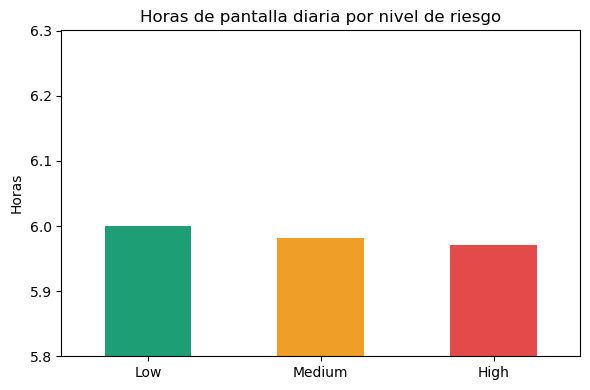

In [ ]:
# 6. HORAS DE PANTALLA POR NIVEL DE RIESGO 
riesgo_pantalla = df.groupby('nivel_riesgo_adiccion')['horas_pantalla_diaria'].mean().reindex(['Low', 'Medium', 'High'])
riesgo_pantalla.plot(kind='bar', figsize=(6, 4), color=['#1D9E75', '#EF9F27', '#E24B4A'])
plt.title('Horas de pantalla diaria por nivel de riesgo')
plt.ylabel('Horas')
plt.ylim(5.8, riesgo_pantalla.max() + 0.3)
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

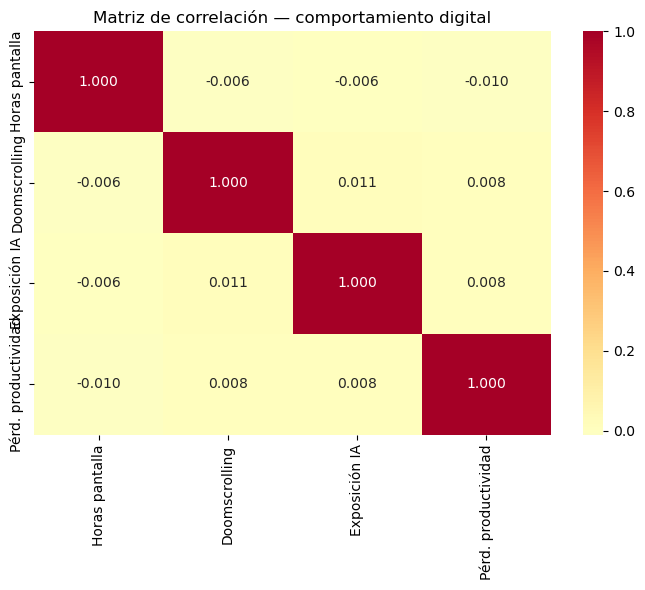

In [ ]:
# --- 7. MATRIZ DE CORRELACIÓN ---
cols_num = ['horas_pantalla_diaria', 'frecuencia_doomscrolling',
            'exposicion_recomendacion_ia', 'pct_perdida_productividad']
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            xticklabels=['Horas pantalla', 'Doomscrolling', 'Exposición IA', 'Pérd. productividad'],
            yticklabels=['Horas pantalla', 'Doomscrolling', 'Exposición IA', 'Pérd. productividad'],
            ax=ax)
ax.set_title('Matriz de correlación — comportamiento digital')
plt.tight_layout()
plt.show()